# Passenger Car Industry: Germany vs. China, Japan and South Korea, 2019–2025

### Production, Sales, and Electrification in Four Major Car Countries

This project compares Germany with three major East Asian car producers — China, Japan and South Korea — over the years 2019 to 2025. The key question: **How did car production, car sales and the adoption of electric cars develop in Germany compared with China, Japan and South Korea since 2019?**

Python is used for loading, cleaning, harmonising and calculating. The cleaned tables are exported for Power BI, where the visualization and interactive analysis take place.

| Area | Scope |
|---|---|
| Countries | Germany (reference country), China, Japan, South Korea |
| Period | 2019–2025, annual (2019 = last full year before COVID, used as base year) |
| Data sources | OICA (passenger car production and sales); IEA Global EV Outlook 2026 data (electric car sales, stock, public charging points) |
| Background only | IEA Global EV Outlook 2026 report and Policy Explorer — stored in the project folder, not analysed in this notebook |
| Output | Four cleaned tables for Power BI in `data/clean/`: country dimension, year dimension, country-year fact table, country summary |

**How this notebook is organised**

| Stage | Sections | What happens |
|---|---|---|
| Setup | 1–2 | Libraries, scope, file paths, country mapping |
| Load | 3–5 | OICA production, OICA sales and IEA EV data are read into clean tables |
| Combine and check | 6–7 | One country-year table; completeness, rounding and cross-source checks |
| Analyse | 8–9 | Growth, index, ratios, country summary; one sanity-check chart |
| Deliver | 10–13 | Star schema, CSV export, limitations, key findings |

Numbers in the text of Sections 7 and 13 are generated by the code from the tables, so they always match the data.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

## 2. Define Scope, File Paths and Country Mapping

The analysis window is 2019–2025: 2019 is the last full year before COVID, and 2025 is the last year available in all three data files.

OICA and the IEA name countries differently (for example `SOUTH KOREA` at OICA but `Korea` at the IEA), so one mapping table links them. It later becomes the country dimension in Power BI.

Run the notebook from the project root (the folder that contains `data/`). Raw files stay untouched in `data/`; cleaned tables are written to `data/clean/`.

In [2]:
START_YEAR = 2019   # last full year before COVID, used as index = 100
END_YEAR = 2025     # last year available in all data files
YEARS = list(range(START_YEAR, END_YEAR + 1))

# Project root = the folder that contains "data/" (also works if the notebook sits in a subfolder)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DIR = DATA_DIR / "clean"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)


def find_file(pattern):
    '''Return the single file in data/ that matches the pattern, or fail with a clear message.'''
    matches = sorted(DATA_DIR.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one file matching '{pattern}' in data/, found {len(matches)}")
    return matches[0]


PRODUCTION_FILE = find_file("prod-passenger-cars-2025.xlsx")     # OICA production: 2019 and 2021-2025
PRODUCTION_2020_FILE = find_file("Passenger-Cars-2020.xlsx")     # OICA production: 2019 and 2020
SALES_FILE = find_file("sales-cars-2025.xlsx")                   # OICA sales: 2019-2025
EV_FILE = find_file("EV*data*by*country*2026.xlsx")              # IEA Global EV Outlook 2026 data, sheet GEVO_EV_2026

dim_country = pd.DataFrame(
    [
        ("DEU", "Germany", "Europe", "GERMANY", "GERMANY", "Germany"),
        ("CHN", "China", "Asia", "CHINA", "CHINA", "China"),
        ("JPN", "Japan", "Asia", "JAPAN", "JAPAN", "Japan"),
        ("KOR", "South Korea", "Asia", "SOUTH KOREA", "SOUTH KOREA", "Korea"),
    ],
    columns=["country_code", "country", "region", "oica_production_name", "oica_sales_name", "iea_name"],
)
dim_country["is_reference"] = dim_country["country_code"] == "DEU"

print("Files found:", [p.name for p in (PRODUCTION_FILE, PRODUCTION_2020_FILE, SALES_FILE, EV_FILE)])
dim_country

Files found: ['prod-passenger-cars-2025.xlsx', 'Passenger-Cars-2020.xlsx', 'sales-cars-2025.xlsx', 'EV data by country 2026.xlsx']


,country_code,country,region,oica_production_name,oica_sales_name,iea_name,is_reference
0,DEU,Germany,Europe,GERMANY,GERMANY,Germany,True
1,CHN,China,Asia,CHINA,CHINA,China,False
2,JPN,Japan,Asia,JAPAN,JAPAN,Japan,False
3,KOR,South Korea,Asia,SOUTH KOREA,SOUTH KOREA,Korea,False


## 3. Load OICA Production Data

**Input:** `prod-passenger-cars-2025.xlsx` and `Passenger-Cars-2020.xlsx` → **Output:** `production` (one row per country and year)

The two OICA production workbooks have different layouts. The 2025 workbook contains 2019 and 2021–2025 but no 2020, so 2020 is taken from the 2020 workbook. Titles, region subtotals and footnotes are skipped; only the four countries are kept. Both workbooks contain 2019, which allows a direct consistency check.

In [3]:
def read_oica_production(path):
    '''Read an OICA production workbook into a long table: country_code, year, production.'''
    raw = pd.read_excel(path, header=None)
    header_row = raw.index[raw[0].astype(str).str.strip() == "UNITS"][0]   # row with 'UNITS', 'YTD 2019', ...
    header = raw.iloc[header_row, 1:].astype(str).str.strip()
    year_cols = {col: int(text.split()[-1]) for col, text in header.items() if text.startswith("YTD")}

    table = raw.iloc[header_row + 1:, [0] + list(year_cols)].copy()
    table.columns = ["name"] + list(year_cols.values())
    table["name"] = table["name"].astype(str).str.strip().str.upper()
    table = table.merge(dim_country[["country_code", "oica_production_name"]],
                        left_on="name", right_on="oica_production_name")
    table = table.melt(id_vars="country_code", value_vars=list(year_cols.values()),
                       var_name="year", value_name="production")
    table["production"] = pd.to_numeric(table["production"], errors="coerce")
    return table


production_main = read_oica_production(PRODUCTION_FILE)
production_2020_file = read_oica_production(PRODUCTION_2020_FILE)

# Consistency check: 2019 appears in both workbooks and should be identical
check_2019 = (
    production_main[production_main["year"] == 2019]
    .merge(production_2020_file[production_2020_file["year"] == 2019],
           on=["country_code", "year"], suffixes=("_2025_file", "_2020_file"))
)
check_2019["identical"] = check_2019["production_2025_file"] == check_2019["production_2020_file"]
display(check_2019)

# 2020 comes from the 2020 workbook, all other years from the 2025 workbook
production = (
    pd.concat([production_main, production_2020_file[production_2020_file["year"] == 2020]])
    .query("@START_YEAR <= year <= @END_YEAR")
    .sort_values(["country_code", "year"])
    .reset_index(drop=True)
)
production.pivot(index="year", columns="country_code", values="production")

,country_code,year,production_2025_file,production_2020_file,identical
0,DEU,2019,4663749,4663749,True
1,CHN,2019,21389833,21389833,True
2,JPN,2019,8329130,8329130,True
3,KOR,2019,3612587,3612587,True


country_code,CHN,DEU,JPN,KOR
year,,,,
2019,21389833,4663749,8329130,3612587
2020,19994081,3515372,6960025,3211706
2021,21444743,3096165,6619245,3162727
2022,23836083,3480357,6566356,3438355
2023,26123757,4109371,7767058,3908747
2024,27476886,4069222,7139188,3849326
2025,30269903,4148836,7207025,3844338


## 4. Load OICA Sales Data

**Input:** `sales-cars-2025.xlsx` → **Output:** `sales` (one row per country and year)

The workbook is titled *"Registrations or sales of new vehicles – passenger cars"*. It does not state which countries report registrations and which report sales, and it contains no definition of "passenger cars".

The layout has the years 2019–2025 as columns. The two extra columns (`2025/2024`, `2025/2019`) are not used here; growth rates are recalculated in Section 8.

In [4]:
def read_oica_sales(path):
    '''Read the OICA sales workbook into a long table: country_code, year, sales.'''
    raw = pd.read_excel(path, header=None)
    header_row = raw.index[raw[0].astype(str).str.strip() == "REGIONS/COUNTRIES"][0]
    header = pd.to_numeric(raw.iloc[header_row, 1:], errors="coerce")        # year headers are numbers (2019.0, ...)
    year_cols = {col: int(year) for col, year in header.items() if year in YEARS}

    table = raw.iloc[header_row + 1:, [0] + list(year_cols)].copy()
    table.columns = ["name"] + list(year_cols.values())
    table["name"] = table["name"].astype(str).str.strip().str.upper()
    table = table.merge(dim_country[["country_code", "oica_sales_name"]],
                        left_on="name", right_on="oica_sales_name")
    table = table.melt(id_vars="country_code", value_vars=list(year_cols.values()),
                       var_name="year", value_name="sales")
    table["sales"] = pd.to_numeric(table["sales"], errors="coerce")
    return table


sales = read_oica_sales(SALES_FILE).sort_values(["country_code", "year"]).reset_index(drop=True)
sales.pivot(index="year", columns="country_code", values="sales")

country_code,CHN,DEU,JPN,KOR
year,,,,
2019,21472091.0,3607258.0,4301091.0,1497035.0
2020,20177731.0,2917678.0,3809981.0,1618333.0
2021,21518324.0,2622132.0,3675698.0,1468873.0
2022,23563287.0,2651357.0,3448297.0,1420486.0
2023,26062824.0,2844609.0,3992727.0,1489363.0
2024,27562989.0,2817331.0,3725200.0,1430765.0
2025,30103140.0,2857591.0,3836380.0,1490208.0


## 5. Load IEA Electric Vehicle Data

**Input:** sheet `GEVO_EV_2026` in the IEA workbook → **Output:** `ev_metrics` (one row per country and year)

The IEA sheet is a long table with one row per country, year, parameter, vehicle mode and powertrain. Only historical values are used (the 2035 projections are dropped). Definitions are taken from the `Definitions` sheet of the IEA workbook; the sales share is not defined there and is described as in the IEA report:

| Metric | IEA parameter | Filter | IEA definition |
|---|---|---|---|
| `ev_sales_bev`, `ev_sales_phev` | EV sales | Cars, BEV / PHEV | New vehicles; registrations where available, otherwise retail sales. BEV = battery only; PHEV includes standard PHEVs and EREVs |
| `ev_sales` | EV sales | Cars, EV | EV = battery-electric and plug-in hybrid vehicles, **not** fuel-cell vehicles |
| `ev_sales_share` | EV sales share | Cars, EV | IEA report, Chapter 1: "sales share of electric cars in the overall car market". Unit in the data: percent, converted to a fraction |
| `ev_stock` | EV stock | Cars, EV | Electric vehicles in operation |
| `public_charging_points` | EV charging points | EVSE, public slow + fast + ultra-fast | Number of power sockets. Slow ≤ 22 kW, fast > 22–150 kW, ultra-fast > 150 kW |

"Cars" means passenger light-duty vehicles, including SUVs and light trucks. Vans, trucks, buses and 2- and 3-wheelers are separate IEA categories and are not used.

The IEA states that all values are rounded to two significant figures. The check below confirms this for every value used here.

In [5]:
ev_raw = pd.read_excel(EV_FILE, sheet_name="GEVO_EV_2026")

ev = ev_raw[
    (ev_raw["category"] == "Historical")                 # drops the 2035 projections
    & (ev_raw["region_country"].isin(dim_country["iea_name"]))
    & (ev_raw["year"].between(START_YEAR, END_YEAR))
].copy()

CHARGER_TYPES = ["Publicly available slow", "Publicly available fast", "Publicly available ultra-fast"]
SELECTION = [   # (IEA parameter, IEA mode, IEA powertrains, column name)
    ("EV sales", "Cars", ["BEV"], "ev_sales_bev"),
    ("EV sales", "Cars", ["PHEV"], "ev_sales_phev"),
    ("EV sales", "Cars", ["EV"], "ev_sales"),
    ("EV sales share", "Cars", ["EV"], "ev_sales_share"),
    ("EV stock", "Cars", ["EV"], "ev_stock"),
    ("EV charging points", "EVSE", CHARGER_TYPES, "public_charging_points"),
]

selected = {
    name: ev[(ev["parameter"] == parameter) & (ev["mode"] == mode) & (ev["powertrain"].isin(powertrains))]
    for parameter, mode, powertrains, name in SELECTION
}

ev_metrics = pd.concat(
    [rows.groupby(["region_country", "year"])["value"].sum(min_count=1).rename(name) for name, rows in selected.items()],
    axis=1,
).reset_index()

# Rounding check: does every IEA value used here have at most 2 significant figures?
used_values = pd.concat(selected.values())["value"]
two_sig_figs = used_values.apply(lambda v: np.isclose(v, float(f"{v:.1e}"), rtol=1e-12, atol=0))
print(f"IEA values used: {len(used_values)} | with at most 2 significant figures: {int(two_sig_figs.sum())}")

# Charger categories without a value (a missing category adds nothing to the sum)
charging = selected["public_charging_points"].pivot_table(
    index=["region_country", "year"], columns="powertrain", values="value", aggfunc="sum")
missing_categories = charging.isna().stack().loc[lambda s: s].reset_index()
print("\nCharger categories with no value, by country:")
print(missing_categories.groupby(["region_country", "powertrain"])["year"]
      .agg(lambda years: ", ".join(map(str, years))).to_string())

ev_metrics["ev_sales_share"] = ev_metrics["ev_sales_share"] / 100      # percent -> fraction
ev_metrics = (
    ev_metrics.merge(dim_country[["country_code", "iea_name"]], left_on="region_country", right_on="iea_name")
    .drop(columns=["region_country", "iea_name"])
    .sort_values(["country_code", "year"])
    .reset_index(drop=True)
)
ev_metrics.head(8)

IEA values used: 213 | with at most 2 significant figures: 213

Charger categories with no value, by country:
region_country  powertrain                   
China           Publicly available ultra-fast                                        2019
Germany         Publicly available ultra-fast                                        2019
Japan           Publicly available ultra-fast    2019, 2020, 2021, 2022, 2023, 2024, 2025
Korea           Publicly available ultra-fast                                  2019, 2020


,year,ev_sales_bev,ev_sales_phev,ev_sales,ev_sales_share,ev_stock,public_charging_points,country_code
0,2019,840000.0,230000.0,1100000.0,0.050,3300000.0,460000.0,CHN
1,2020,930000.0,220000.0,1100000.0,0.057,4400000.0,540000.0,CHN
2,2021,2700000.0,550000.0,3300000.0,0.160,7700000.0,865000.0,CHN
3,2022,4500000.0,1500000.0,6000000.0,0.290,13000000.0,1460000.0,CHN
4,2023,5500000.0,2700000.0,8100000.0,0.380,21000000.0,2330000.0,CHN
5,2024,6400000.0,4900000.0,11000000.0,0.480,32000000.0,3300000.0,CHN
6,2025,8200000.0,5100000.0,13000000.0,0.530,44000000.0,4680000.0,CHN
7,2019,63000.0,45000.0,110000.0,0.030,240000.0,29200.0,DEU


## 6. Combine the Sources into One Country-Year Table

A complete grid of every country and every year (4 countries × 7 years = 28 rows) is built first. The three sources are then joined onto it with left joins, so a missing value in any source shows up as a gap instead of silently dropping a row.

`ev_sales` is the IEA total for electric cars (powertrain `EV`). BEV and PHEV are rounded separately by the IEA, so `ev_sales_bev + ev_sales_phev` can differ from `ev_sales`; Section 7 measures this difference.

In [6]:
grid = pd.MultiIndex.from_product(
    [dim_country["country_code"], YEARS], names=["country_code", "year"]
).to_frame(index=False)

country_year = (
    grid
    .merge(production, on=["country_code", "year"], how="left")
    .merge(sales, on=["country_code", "year"], how="left")
    .merge(ev_metrics, on=["country_code", "year"], how="left")
)

print("Rows:", len(country_year), "| Columns:", len(country_year.columns))
country_year.head()

Rows: 28 | Columns: 10


,country_code,year,production,sales,ev_sales_bev,ev_sales_phev,ev_sales,ev_sales_share,ev_stock,public_charging_points
0,DEU,2019,4663749,3607258.0,63000.0,45000.0,110000.0,0.03,240000.0,29200.0
1,DEU,2020,3515372,2917678.0,190000.0,200000.0,390000.0,0.14,610000.0,43300.0
2,DEU,2021,3096165,2622132.0,360000.0,330000.0,680000.0,0.26,1200000.0,59500.0
3,DEU,2022,3480357,2651357.0,470000.0,360000.0,830000.0,0.31,1900000.0,86100.0
4,DEU,2023,4109371,2844609.0,520000.0,180000.0,700000.0,0.24,2600000.0,110100.0


## 7. Data Quality Checks

Three checks before any metric is calculated:

1. **Completeness** — every country-year has a value in every column and appears exactly once.
2. **BEV + PHEV vs. IEA EV total** — measures how far the separately rounded BEV and PHEV values add up to the IEA total.
3. **OICA vs. IEA market size** — dividing the IEA electric car sales by the IEA EV sales share gives the new-car market size implied by the IEA. Because all IEA values are rounded to two significant figures, the true implied market lies within a *rounding band*: the lowest and highest value the rounded inputs allow. If the OICA sales figure lies inside the band, the two sources are consistent; if it lies outside, they are not.

In [7]:
expected_rows = len(dim_country) * len(YEARS)
missing = country_year.isna().sum()

print(f"Rows: {len(country_year)} (expected {expected_rows})")
print("Duplicate country-year rows:", int(country_year.duplicated(["country_code", "year"]).sum()))
print("Columns with missing values:", missing[missing > 0].to_dict() or "none")

assert len(country_year) == expected_rows
assert missing.sum() == 0

Rows: 28 (expected 28)
Duplicate country-year rows: 0
Columns with missing values: none


In [8]:
def half_step(value, digits=2):
    '''Half of the last kept digit of a value rounded to `digits` significant figures.
    A published value v stands for a true value between v - half_step and v + half_step.'''
    return 0.5 * 10 ** (np.floor(np.log10(np.abs(value))) - digits + 1)


# Check 2: BEV + PHEV vs. IEA EV total
parts = country_year["ev_sales_bev"] + country_year["ev_sales_phev"]
parts_tolerance = half_step(country_year["ev_sales_bev"]) + half_step(country_year["ev_sales_phev"])
total_tolerance = half_step(country_year["ev_sales"])
difference = parts / country_year["ev_sales"] - 1
within_rounding = ((parts - parts_tolerance) <= (country_year["ev_sales"] + total_tolerance)) & \
                  ((parts + parts_tolerance) >= (country_year["ev_sales"] - total_tolerance))

largest = difference.abs().idxmax()
print(f"BEV + PHEV vs. IEA EV total: largest difference {difference[largest]:+.1%} "
      f"({country_year.loc[largest, 'country_code']} {country_year.loc[largest, 'year']}); "
      f"country-years consistent within IEA rounding: {int(within_rounding.sum())} of {len(country_year)}")

BEV + PHEV vs. IEA EV total: largest difference -6.4% (KOR 2022); country-years consistent within IEA rounding: 28 of 28


In [9]:
# Check 3: market size implied by the IEA vs. OICA sales
share = country_year["ev_sales_share"]
total = country_year["ev_sales"]

country_year["iea_implied_market"] = total / share
band_low = (total - half_step(total)) / (share + half_step(share))
band_high = (total + half_step(total)) / (share - half_step(share))

country_year["iea_vs_oica_market_ratio"] = country_year["iea_implied_market"] / country_year["sales"]
country_year["oica_within_iea_band"] = country_year["sales"].between(band_low, band_high)

ratio_table = country_year.pivot(index="year", columns="country_code", values="iea_vs_oica_market_ratio").round(3)
print("IEA-implied market / OICA sales (1.000 = identical):")
display(ratio_table)

IEA-implied market / OICA sales (1.000 = identical):


country_code,CHN,DEU,JPN,KOR
year,,,,
2019,1.025,1.016,1.007,1.002
2020,0.956,0.955,0.989,0.989
2021,0.958,0.997,0.998,0.983
2022,0.878,1.010,0.994,1.027
2023,0.818,1.025,1.002,0.981
2024,0.831,1.012,0.959,1.228
2025,0.815,1.003,0.869,1.342


In [10]:
# Generated summary of check 3 (every number comes from the table above)
outside = country_year[~country_year["oica_within_iea_band"]].merge(
    dim_country[["country_code", "country"]], on="country_code")

lines = []
for country, rows in outside.groupby("country", sort=False):
    entries = ", ".join(f"{int(r.year)} ({r.iea_vs_oica_market_ratio:.2f})" for r in rows.itertuples())
    lines.append(f"- **{country}:** {entries}")
all_inside = [c for c in dim_country["country"] if c not in set(outside["country"])]

band_summary = (
    "OICA sales **outside** the IEA rounding band — year (IEA-implied market ÷ OICA sales):\n\n"
    + "\n".join(lines)
    + f"\n\nInside the band in all {len(YEARS)} years: {', '.join(all_inside) if all_inside else 'none'}.\n\n"
    + "The data files do not state the reasons for these differences; Section 12 lists what published sources show. OICA volumes and IEA shares are therefore "
      "not combined in any metric except this cross-check."
)
display(Markdown(band_summary))

OICA sales **outside** the IEA rounding band — year (IEA-implied market ÷ OICA sales):

- **China:** 2022 (0.88), 2023 (0.82), 2024 (0.83), 2025 (0.81)
- **Japan:** 2025 (0.87)
- **South Korea:** 2021 (0.98), 2024 (1.23), 2025 (1.34)

Inside the band in all 7 years: Germany.

The data files do not state the reasons for these differences; Section 12 lists what published sources show. OICA volumes and IEA shares are therefore not combined in any metric except this cross-check.

## 8. Calculate Metrics

Growth, index and ratio metrics are added to the country-year table, then condensed into one summary row per country.

| Metric | Definition |
|---|---|
| `*_yoy` | Change versus the previous year |
| `*_index` | Value divided by the 2019 value × 100 (2019 = 100), so countries of different size can be compared |
| `production_to_sales_ratio` | OICA production divided by OICA sales of the same country. Above 1: more cars are produced than sold, as counted by OICA. The files contain no trade data, so it is not an export figure |
| `bev_share_of_ev_sales` | BEV / (BEV + PHEV), using the separately rounded IEA values |
| `production_cagr` | Compound annual growth rate of production, 2019 to 2025 (6 years) |
| `production_recovery_year` | First year after 2019 in which production is at or above the 2019 level |

All shares and growth rates are stored as fractions (0.25 = 25 %).

In [11]:
country_year = country_year.sort_values(["country_code", "year"]).reset_index(drop=True)
by_country = country_year.groupby("country_code")

country_year["production_to_sales_ratio"] = country_year["production"] / country_year["sales"]
country_year["bev_share_of_ev_sales"] = country_year["ev_sales_bev"] / (
    country_year["ev_sales_bev"] + country_year["ev_sales_phev"])

for column in ["production", "sales", "ev_sales"]:
    country_year[f"{column}_yoy"] = by_country[column].pct_change()

for column in ["production", "sales"]:
    country_year[f"{column}_index"] = country_year[column] / by_country[column].transform("first") * 100

country_year.tail()

,country_code,year,production,sales,ev_sales_bev,ev_sales_phev,ev_sales,ev_sales_share,ev_stock,public_charging_points,iea_implied_market,iea_vs_oica_market_ratio,oica_within_iea_band,production_to_sales_ratio,bev_share_of_ev_sales,production_yoy,sales_yoy,ev_sales_yoy,production_index,sales_index
23,KOR,2021,3162727,1468873.0,72000.0,19000.0,91000.0,0.063,240000.0,101053.0,1.444444e+06,0.983369,False,2.153166,0.791209,-0.015250,-0.092354,1.275000,87.547428,98.118815
24,KOR,2022,3438355,1420486.0,120000.0,11000.0,140000.0,0.096,360000.0,201100.0,1.458333e+06,1.026644,True,2.420548,0.916031,0.087149,-0.032942,0.538462,95.177085,94.886626
25,KOR,2023,3908747,1489363.0,120000.0,12000.0,130000.0,0.089,490000.0,304150.0,1.460674e+06,0.980738,True,2.624442,0.909091,0.136807,0.048488,-0.071429,108.198003,99.487520
26,KOR,2024,3849326,1430765.0,120000.0,7900.0,130000.0,0.074,620000.0,417160.0,1.756757e+06,1.227844,False,2.690397,0.938233,-0.015202,-0.039344,0.000000,106.553171,95.573250
27,KOR,2025,3844338,1490208.0,200000.0,17000.0,220000.0,0.110,840000.0,491170.0,2.000000e+06,1.342095,False,2.579732,0.921659,-0.001296,0.041546,0.692308,106.415098,99.543965


In [12]:
summary_rows = []
for code, df in country_year.groupby("country_code"):
    first, last = df.iloc[0], df.iloc[-1]                     # 2019 and 2025
    n_years = last["year"] - first["year"]
    back_at_2019 = df[(df["year"] > first["year"]) & (df["production"] >= first["production"])]

    summary_rows.append({
        "country_code": code,
        "production_2019": first["production"],
        "production_2025": last["production"],
        "production_change": last["production"] / first["production"] - 1,
        "production_cagr": (last["production"] / first["production"]) ** (1 / n_years) - 1,
        "production_change_2020": df.loc[df["year"] == 2020, "production"].iloc[0] / first["production"] - 1,
        "production_recovery_year": back_at_2019["year"].min() if len(back_at_2019) else np.nan,
        "sales_2019": first["sales"],
        "sales_2025": last["sales"],
        "sales_change": last["sales"] / first["sales"] - 1,
        "production_to_sales_ratio_2025": last["production_to_sales_ratio"],
        "ev_sales_share_2019": first["ev_sales_share"],
        "ev_sales_share_2025": last["ev_sales_share"],
        "ev_sales_share_change": last["ev_sales_share"] - first["ev_sales_share"],
        "ev_sales_2025": last["ev_sales"],
        "ev_stock_2025": last["ev_stock"],
        "public_charging_points_2025": last["public_charging_points"],
    })

country_summary = pd.DataFrame(summary_rows)
country_summary["production_recovery_year"] = country_summary["production_recovery_year"].astype("Int64")
country_summary = dim_country[["country_code", "country"]].merge(country_summary, on="country_code")
country_summary

,country_code,country,production_2019,production_2025,production_change,production_cagr,production_change_2020,production_recovery_year,sales_2019,sales_2025,sales_change,production_to_sales_ratio_2025,ev_sales_share_2019,ev_sales_share_2025,ev_sales_share_change,ev_sales_2025,ev_stock_2025,public_charging_points_2025
0,DEU,Germany,4663749,4148836,-0.110408,-0.019310,-0.246235,<NA>,3607258.0,2857591.0,-0.207822,1.451865,0.030,0.30,0.270,860000.0,3100000.0,199000.0
1,CHN,China,21389833,30269903,0.415154,0.059580,-0.065253,2021,21472091.0,30103140.0,0.401966,1.005540,0.050,0.53,0.480,13000000.0,44000000.0,4680000.0
2,JPN,Japan,8329130,7207025,-0.134721,-0.023829,-0.164376,<NA>,4301091.0,3836380.0,-0.108045,1.878600,0.009,0.03,0.021,100000.0,720000.0,39000.0
3,KOR,South Korea,3612587,3844338,0.064151,0.010417,-0.110968,2023,1497035.0,1490208.0,-0.004560,2.579732,0.024,0.11,0.086,220000.0,840000.0,491170.0


## 9. Quick Visual Check (Optional)

Charts are kept to a minimum in this notebook since the interactive visualization and analysis happen in Power BI. This single figure is only a sanity check, confirming that the indexed series and the EV shares look plausible before export — it is not part of the delivered analysis. Each panel has a short explanation of its scale below the x-axis. Germany is drawn as the thick line.

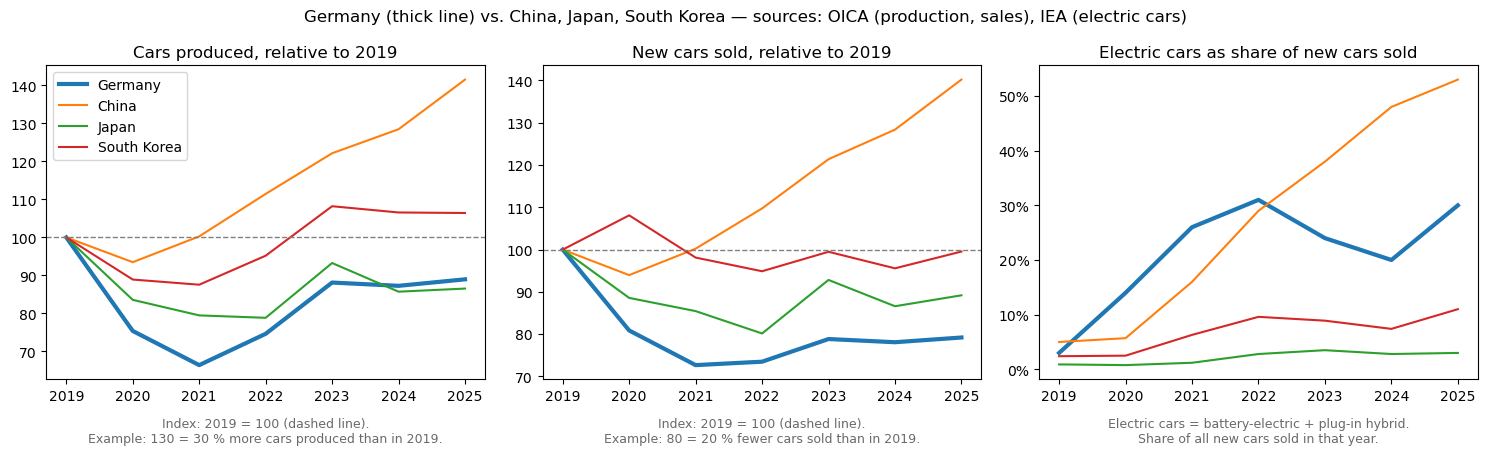

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
panels = [
    ("production_index", "Cars produced, relative to 2019",
     "Index: 2019 = 100 (dashed line).\nExample: 130 = 30 % more cars produced than in 2019."),
    ("sales_index", "New cars sold, relative to 2019",
     "Index: 2019 = 100 (dashed line).\nExample: 80 = 20 % fewer cars sold than in 2019."),
    ("ev_sales_share", "Electric cars as share of new cars sold",
     "Electric cars = battery-electric + plug-in hybrid.\nShare of all new cars sold in that year."),
]

for ax, (column, title, caption) in zip(axes, panels):
    for code, name in zip(dim_country["country_code"], dim_country["country"]):
        sub = country_year[country_year["country_code"] == code]
        ax.plot(sub["year"], sub[column], label=name, linewidth=3 if code == "DEU" else 1.5)
    if column.endswith("_index"):
        ax.axhline(100, color="grey", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(caption, fontsize=9, color="dimgrey", labelpad=10)

axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend()
fig.suptitle("Germany vs. China, Japan, South Korea — sources: OICA (production, sales), IEA (electric cars)")
plt.tight_layout()
plt.show()

## 10. Build the Star Schema for Power BI

The four exported tables form a small star schema rather than a set of unrelated CSVs.

| Table | Type | Grain | Purpose | Key |
|---|---|---|---|---|
| `dim_country` | Dimension | One row per country | Country name, region, reference-country flag | `country_code` |
| `dim_year` | Dimension | One row per year | Year and base-year flag for slicers | `year` |
| `fact_country_year` | Fact | Country × year (28 rows) | Production, sales, EV metrics, derived ratios and the source cross-check | `country_code` + `year` |
| `country_summary` | Fact (1:1 with `dim_country`) | One row per country | 2019 vs. 2025 headline metrics | `country_code` |

`fact_country_year` relates to `dim_country` on `country_code` and to `dim_year` on `year` (both many-to-one); `country_summary` relates to `dim_country` on `country_code` (one-to-one). All shares and growth rates are fractions and should be formatted as percentages in Power BI.

## 11. Export Tables for Power BI

In [14]:
dim_year = pd.DataFrame({"year": YEARS})
dim_year["is_base_year"] = dim_year["year"] == START_YEAR

fact_columns = [
    "country_code", "year",
    "production", "sales", "production_to_sales_ratio",
    "production_yoy", "sales_yoy", "production_index", "sales_index",
    "ev_sales_bev", "ev_sales_phev", "ev_sales", "ev_sales_yoy", "bev_share_of_ev_sales",
    "ev_sales_share", "ev_stock", "public_charging_points",
    "iea_vs_oica_market_ratio", "oica_within_iea_band",
]

exports = {
    "dim_country": dim_country[["country_code", "country", "region", "is_reference"]],
    "dim_year": dim_year,
    "fact_country_year": country_year[fact_columns],
    "country_summary": country_summary,
}

for name, table in exports.items():
    table.to_csv(CLEAN_DIR / f"{name}.csv", index=False)
    print(f"{name}.csv: {table.shape[0]} rows x {table.shape[1]} columns")

dim_country.csv: 4 rows x 4 columns
dim_year.csv: 7 rows x 2 columns
fact_country_year.csv: 28 rows x 19 columns
country_summary.csv: 4 rows x 18 columns


## 12. Limitations

**Time window.** Seven annual values per country (2019–2025). The analysis compares developments over time and does not test causes. 2026 is not included: the OICA sales data and the IEA historical data used here end in 2025.

**Definitions differ between the sources.**
- OICA sales are titled *"Registrations or sales of new vehicles – passenger cars"*. The workbook does not say which countries report registrations and which report sales, and it does not define "passenger cars".
- IEA "Cars" are passenger light-duty vehicles including SUVs and light trucks. IEA sales are new registrations where available and retail sales otherwise (IEA `Definitions` sheet).

**OICA sales vs. IEA market size.** Section 7 lists every country-year in which the OICA sales figure lies outside the IEA rounding band: China 2022–2025, Japan 2025 and South Korea 2021, 2024 and 2025. The data files do not state the reasons. Below is what published sources show. *Implied market* = IEA EV sales ÷ IEA EV sales share; the *band* is the range allowed by the IEA's two-significant-figure rounding (Section 7). Values marked "calculated" are derived in this notebook from the cited numbers.

**China, 2022–2025 — explained.**
- The OICA figure for China is CAAM's passenger vehicle sales *including exports*. 2025: OICA 30,103,140; CAAM 30.103 million, of which 6.038 million exports and 24.065 million domestic sales ([Gasgoo, CAAM 2025](https://autonews.gasgoo.com/articles/news/chinas-2025-auto-market-hits-new-highs-in-both-annual-sales-output-2011438280283627520)). 2024: OICA 27,562,989; CAAM 27.563 million passenger vehicles, of which 4.955 million exports ([Gasgoo, CAAM 2024](https://autonews.gasgoo.com/china_news/70035689.html)). 2023: OICA 26,062,824; CAAM 26.06 million, up 10.6 % on 2022 ([Mysteel](https://www.mysteel.net/news/5046713-caam-chinas-2023-auto-sales-output-both-hit-record-highs)). 2022: OICA 23,563,287; the OICA growth from 2022 to 2023 is +10.6 % (calculated), the same as the CAAM growth. Passenger vehicle exports in 2022 were 2.529 million ([CarNewsChina](https://carnewschina.com/2023/01/28/china-exported-more-than-3-million-vehicles-in-2022-54-4-yoy-increase/)).
- CAAM counts a car as sold when it is sold to a dealer, i.e. wholesale ([CnEVPost](https://cnevpost.com/2021/09/10/explainer-what-is-the-difference-between-cpca-and-caams-china-auto-sales-data/)), and its figures include exports ([Just Auto](https://www.just-auto.com/features/china-made-vehicle-sales-rise-4-5-in-2024/)).
- The IEA counts new registrations, or retail sales where only those are available (IEA `Definitions` sheet). The IEA `Notes` sheet lists CATARC among its sources but does not say which source is used for which country.
- Check (calculated): OICA sales minus the exports above lie inside the IEA band in 2022 (21,034,287; band 20,169,492–21,228,070), 2024 (22,607,989; band 21,649,485–24,210,526) and 2025 (24,065,140; band 23,364,486–25,714,286). For 2023, the China Passenger Car Association's 21.7 million passenger cars sold ([gov.cn](https://english.www.gov.cn/archive/statistics/202401/09/content_WS659d4966c6d0868f4e8e2e64.html), rounded as published) lie inside the band 20,909,091–21,733,333. The OICA totals lie outside the band in all four years.

**Japan, 2025 — not explained.**
- The OICA figure for Japan matches the passenger car sales of the Japan Automobile Manufacturers Association, which include mini (kei) cars: 3.99 million in 2023 and 3.73 million in 2024 ([JAMA, Motor Industry of Japan 2025](https://www.jama.or.jp/english/reports/docs/MIoJ2025_e.pdf)); OICA: 3,992,727 and 3,725,200.
- In 2025, total new vehicle sales in Japan (including trucks, buses and kei cars) rose 3.3 % to 4,565,777 ([nippon.com](https://www.nippon.com/en/japan-data/h02659/)). OICA passenger car sales rose 3.0 % (calculated: 3,725,200 → 3,836,380).
- The IEA report states that EV sales were "just above 100 000" and "less than 3% of sales" in 2025 ([IEA, Global EV Outlook 2026](https://www.iea.org/reports/global-ev-outlook-2026), Chapter 1). The IEA data file gives 100,000 and 3.0 %, an implied market of 3,333,333 (band 3,114,754–3,559,322). With OICA's 3,836,380 passenger cars, 100,000 EVs would be a share of 2.6 % (calculated).
- No source was found that explains the difference.

**South Korea, 2021, 2024 and 2025 — not explained.**
- 2025: the Korea Automobile & Mobility Association (KAMA) reported 220,177 EV registrations (+50.1 %) and a 13.1 % share of new vehicle purchases ([Ajupress](https://www.ajupress.com/view/20260120133100778)), which implies a market of 1,680,740 (calculated). The IEA data file gives 220,000 EVs and 11 %, an implied market of 2,000,000 (band 1,869,565–2,142,857). OICA: 1,490,208.
- 2024: KAMA and KAIDA members together sold 1,601,540 vehicles ([Fourin, AAA Weekly](https://aaa.fourin.com/reports/2cec1290-62dd-11f0-84dd-33f77ad83d98/south-koreas-2024-automobile-sales-by-segment); the free preview does not show the split between passenger and commercial vehicles). The IEA-implied market is 1,756,757 (band 1,677,852–1,836,735), which lies entirely above that total. OICA: 1,430,765.
- 2021: the IEA-implied market is 98.3 % of the OICA figure (1,468,873; Section 7). No source was checked for this small difference.
- No source was found that explains the differences.

**Production data.**
- 2020 comes from the 2020 OICA release and all other years from the 2025 release. A one-time comparison with the 2023 release (not part of the project data) showed: Germany 3,515,372 vs. 3,515,488 and Japan 6,960,025 vs. 6,960,411; China and South Korea were identical.
- Both OICA production workbooks have a legend that marks estimated values (grey cell) and "Audi, BMW, JLR, data not reported" (blue cell). None of the production values of the four countries carries either colour (checked by cell colour in both workbooks).
- `production_to_sales_ratio` compares production in a country with sales in the same country. The files contain no trade data, so it is not an export figure.

**IEA rounding.** All IEA values are rounded to two significant figures (IEA `Notes` sheet; confirmed for every value used in Section 5). For example, the IEA EV total for China in 2025 is 13,000,000, which stands for a true value between 12,500,000 and 13,500,000. Because BEV and PHEV are rounded separately, `ev_sales_bev + ev_sales_phev` can differ from `ev_sales`; Section 7 shows the largest difference. The text of the IEA report says that electric cars accounted for "nearly 55%" of all car sales in China in 2025; the data file used here gives 53 %. This notebook uses the data file.

**Public charging points.** The IEA counts power sockets, not charging stations. A missing charger category adds nothing to the sum; Section 5 lists the missing categories (ultra-fast for China 2019, Germany 2019, Japan 2019–2025 and South Korea 2019–2020). The sum of three rounded categories shows more digits than the data's precision.

**Not covered.** Prices, individual manufacturers, imports and exports, and policy measures are not analysed.

## 13. Summary and Key Findings

The findings below are generated from the tables in Sections 7 and 8, so every number is taken directly from the data. Production and sales are OICA figures; electric vehicle figures are IEA figures (rounded to two significant figures).

In [15]:
summary = country_summary.set_index("country")
by_year = country_year.merge(dim_country[["country_code", "country"]], on="country_code").set_index(["country", "year"])


def pct(value):
    return ("−" if value < 0 else "+") + f"{abs(value) * 100:.1f} %"


def count(value):
    return f"{value:,.0f}"


def ev_share(value):                       # IEA shares have two significant figures
    return f"{value * 100:.2g} %"


def ranking(column):
    values = summary[column].sort_values(ascending=False)
    return "; ".join(f"{country} {count(value)}" for country, value in values.items())


production_sorted = summary.sort_values("production_change", ascending=False)
sales_sorted = summary.sort_values("sales_change", ascending=False)
covid = summary.sort_values("production_change_2020")
share_sorted = summary.sort_values("ev_sales_share_2025", ascending=False)
recovered = summary["production_recovery_year"].dropna().astype(int)
not_recovered = list(summary.index[summary["production_recovery_year"].isna()])

de = by_year.loc["Germany"]
cn_share = by_year.loc["China", "ev_sales_share"]
de_share = by_year.loc["Germany", "ev_sales_share"]
de_peak_year = de_share.idxmax()

ranks = {
    f"production change {START_YEAR}–{END_YEAR}": summary["production_change"].rank(ascending=False)["Germany"],
    f"sales change {START_YEAR}–{END_YEAR}": summary["sales_change"].rank(ascending=False)["Germany"],
    f"EV share of new car sales {END_YEAR}": summary["ev_sales_share_2025"].rank(ascending=False)["Germany"],
}

findings = [
    f"- **Production {START_YEAR} → {END_YEAR}:** "
    + "; ".join(f"{c} {pct(r.production_change)} ({count(r.production_2019)} → {count(r.production_2025)} cars)"
                for c, r in production_sorted.iterrows()) + ".",

    "- **Back at the 2019 production level:** "
    + (", ".join(f"{c} (first in {y})" for c, y in recovered.items()) or "none")
    + f". Not back at the 2019 level by {END_YEAR}: {', '.join(not_recovered) or 'none'}.",

    "- **Production change 2020 vs. 2019:** "
    + "; ".join(f"{c} {pct(r.production_change_2020)}" for c, r in covid.iterrows()) + ".",

    f"- **Sales {START_YEAR} → {END_YEAR} (OICA):** "
    + "; ".join(f"{c} {pct(r.sales_change)} ({count(r.sales_2019)} → {count(r.sales_2025)} cars)"
                for c, r in sales_sorted.iterrows())
    + ". For China, the OICA sales figure includes exports (Section 12); Section 7 shows where OICA sales "
      "and the IEA-implied market differ.",

    f"- **Production-to-sales ratio:** Germany {de.loc[START_YEAR, 'production_to_sales_ratio']:.2f} ({START_YEAR}) → "
    f"{de.loc[END_YEAR, 'production_to_sales_ratio']:.2f} ({END_YEAR}); in the same period German production changed by "
    f"{pct(summary.loc['Germany', 'production_change'])} and German sales by {pct(summary.loc['Germany', 'sales_change'])}. "
    f"Ratio in {END_YEAR}: "
    + "; ".join(f"{c} {r.production_to_sales_ratio_2025:.2f}"
                for c, r in summary.sort_values("production_to_sales_ratio_2025", ascending=False).iterrows()) + ".",

    f"- **EV share of new car sales {START_YEAR} → {END_YEAR} (IEA):** "
    + "; ".join(f"{c} {ev_share(r.ev_sales_share_2019)} → {ev_share(r.ev_sales_share_2025)}"
                for c, r in share_sorted.iterrows()) + ".",

    "- **EV share by year:** Germany "
    + ", ".join(f"{ev_share(v)} ({y})" for y, v in de_share.items())
    + f" (highest in {de_peak_year}). China's share "
    + ("rose in every year." if (cn_share.diff().dropna() > 0).all() else "did not rise in every year."),

    f"- **Electric car volumes {END_YEAR} (IEA):** EV sales — {ranking('ev_sales_2025')}. "
    f"EV stock — {ranking('ev_stock_2025')}. "
    f"Public charging points — {ranking('public_charging_points_2025')} (sums of rounded categories).",

    "- **Germany's rank among the four countries (1 = highest):** "
    + ", ".join(f"{label}: {int(rank)} of {len(summary)}" for label, rank in ranks.items()) + ".",

    "- **Data caveat:** OICA sales and the market size implied by the IEA differ in several country-years (Section 7). "
    "Apart from that cross-check, no metric combines OICA sales volumes with IEA shares.",
]

display(Markdown("\n".join(findings)))

- **Production 2019 → 2025:** China +41.5 % (21,389,833 → 30,269,903 cars); South Korea +6.4 % (3,612,587 → 3,844,338 cars); Germany −11.0 % (4,663,749 → 4,148,836 cars); Japan −13.5 % (8,329,130 → 7,207,025 cars).
- **Back at the 2019 production level:** China (first in 2021), South Korea (first in 2023). Not back at the 2019 level by 2025: Germany, Japan.
- **Production change 2020 vs. 2019:** Germany −24.6 %; Japan −16.4 %; South Korea −11.1 %; China −6.5 %.
- **Sales 2019 → 2025 (OICA):** China +40.2 % (21,472,091 → 30,103,140 cars); South Korea −0.5 % (1,497,035 → 1,490,208 cars); Japan −10.8 % (4,301,091 → 3,836,380 cars); Germany −20.8 % (3,607,258 → 2,857,591 cars). For China, the OICA sales figure includes exports (Section 12); Section 7 shows where OICA sales and the IEA-implied market differ.
- **Production-to-sales ratio:** Germany 1.29 (2019) → 1.45 (2025); in the same period German production changed by −11.0 % and German sales by −20.8 %. Ratio in 2025: South Korea 2.58; Japan 1.88; Germany 1.45; China 1.01.
- **EV share of new car sales 2019 → 2025 (IEA):** China 5 % → 53 %; Germany 3 % → 30 %; South Korea 2.4 % → 11 %; Japan 0.9 % → 3 %.
- **EV share by year:** Germany 3 % (2019), 14 % (2020), 26 % (2021), 31 % (2022), 24 % (2023), 20 % (2024), 30 % (2025) (highest in 2022). China's share rose in every year.
- **Electric car volumes 2025 (IEA):** EV sales — China 13,000,000; Germany 860,000; South Korea 220,000; Japan 100,000. EV stock — China 44,000,000; Germany 3,100,000; South Korea 840,000; Japan 720,000. Public charging points — China 4,680,000; South Korea 491,170; Germany 199,000; Japan 39,000 (sums of rounded categories).
- **Germany's rank among the four countries (1 = highest):** production change 2019–2025: 3 of 4, sales change 2019–2025: 4 of 4, EV share of new car sales 2025: 2 of 4.
- **Data caveat:** OICA sales and the market size implied by the IEA differ in several country-years (Section 7). Apart from that cross-check, no metric combines OICA sales volumes with IEA shares.